# 02 — Feature Engineering

**Aim:** In this notebook I try to extract features from raw game data. The idea is to find correlations between data that indicate the game result and can be used to train a ML model.


**Critical Rule — No Data Leakage!**
Features for game X may **only** use information from games before X. If I mix in the actual result or future games, the model peforms in training amazing **but** but falls apart in reality. 


**Features I am going to build:**
1. **Rolling Team Form** — win rate and point differential over last 5 / 10 / 20 games
2. **Rest Days** — days since the last game (back-to-back detection)
3. **ELO Rating** — classic chess system, updated across all games
4. **Head-to-Head** — win rate vs the specific opponent in the last 5 meetings
5. **Home/Away** — indicator 

The main idea here is to first find the features. Once they show sufficient correlation the next step is to weigh the features. In the next steps I will first work them out:

## 1. Loading data

In [3]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

pd.set_option("display.max_columns", 50)

DATA_RAW = Path("..") / "data" / "raw" # Kaggle files
DATA_PROCESSED = Path("..") / "data" / "processed" # my own results / modified files
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

games = pd.read_csv(DATA_RAW / "Games.csv", parse_dates=["gameDate"], low_memory=False) # loading games
print(f"Loaded: {len(games):,} games")

Loaded: 73,224 games


## 2. Cleaning the dataset

- keep only games with valid scores (NaN)
- filter out future / scheduled games (see above critical rule)
- sort by date — critical for everything time-dependent below
- reduce to relevant columns
- only Regular Season + Playoffs (no Pre-Season, All-Star ... no one cares haha)

In [19]:

total_games = games.gameType.value_counts(dropna=False).sum()
print(f"Game types before filter:: {total_games:,}")
#print(games.gameType.value_counts(dropna=False).sum())

#filter 
valid_types = ["Regular Season", "Playoffs"]
df = games[
    games.gameType.isin(valid_types)
    & games.homeScore.notna()
    & games.awayScore.notna()
].copy()

# sort by date
df = df[[
    "gameId", "gameDate", "gameType",
    "hometeamId", "hometeamName",
    "awayteamId", "awayteamName",
    "homeScore", "awayScore",
]].sort_values("gameDate").reset_index(drop=True)

# adding important columns: WIN, Point difference and season
df["home_win"] = (df.homeScore > df.awayScore).astype(int)
df["point_diff"] = df.homeScore - df.awayScore
df["season"] = np.where(df.gameDate.dt.month >= 10, df.gameDate.dt.year, df.gameDate.dt.year - 1)

print(f"\nAfter filter: {len(df):,} games")
print(f"Range: {df.gameDate.min().date()} - {df.gameDate.max().date()}")
df.head()

Game types before filter:: 73,224

After filter: 71,239 games
Range: 1946-11-26 - 2026-04-26


,gameId,gameDate,gameType,hometeamId,hometeamName,awayteamId,awayteamName,homeScore,awayScore,home_win,point_diff,season
0,24600052,1946-11-26 19:00:00,Regular Season,1610612744,Warriors,1610612738,Celtics,66,54,1,12,1946
1,24600063,1946-11-30 19:00:00,Regular Season,1610612752,Knicks,1610612744,Warriors,64,60,1,4,1946
2,24600076,1946-12-05 19:00:00,Regular Season,1610612744,Warriors,1610612752,Knicks,62,51,1,11,1946
3,24600078,1946-12-07 19:00:00,Regular Season,1610612738,Celtics,1610612752,Knicks,65,90,0,-25,1946
4,24600083,1946-12-08 19:00:00,Regular Season,1610612752,Knicks,1610612738,Celtics,62,44,1,18,1946


## 3. Reshaping Games to Teams

**Situation**: Currently this df only lists games. But I am interested in Team performance. Therefore, I split every game in **2 rows**. Once showing the home teams perspective, once from the away teams perspective.
 I am not double counting these events, just gives me better overview of the team performance.


In [20]:
# splitting in two data subsets... adding is_home as column (here int but could also be boole)
home = df.rename(columns={
    "hometeamId": "teamId", "hometeamName": "teamName",
    "awayteamId": "oppId", "awayteamName": "oppName",
    "homeScore": "pts", "awayScore": "opp_pts",
})[["gameId", "gameDate", "season", "teamId", "teamName", "oppId", "oppName", "pts", "opp_pts"]].copy()
home["is_home"] = 1

away = df.rename(columns={
    "awayteamId": "teamId", "awayteamName": "teamName",
    "hometeamId": "oppId", "hometeamName": "oppName",
    "awayScore": "pts", "homeScore": "opp_pts",
})[["gameId", "gameDate", "season", "teamId", "teamName", "oppId", "oppName", "pts", "opp_pts"]].copy()
away["is_home"] = 0

# Here I combine again because I want to see if one team always wins... so eg BOS vs. Nuggets 90% win rate 
team_games = pd.concat([home, away], ignore_index=True)
team_games["win"] = (team_games.pts > team_games.opp_pts).astype(int) # checking for win
team_games["margin"] = team_games.pts - team_games.opp_pts # by how many points
team_games = team_games.sort_values(["teamId", "gameDate"]).reset_index(drop=True) # sorting by team first and by date within each team

print(f"{len(team_games):,} team-game rows ({len(df):,} games x 2)")
team_games.head(7)

142,478 team-game rows (71,239 games x 2)


,gameId,gameDate,season,teamId,teamName,oppId,oppName,pts,opp_pts,is_home,win,margin
0,24900018,1949-11-05 19:00:00,1949,1610612737,Blackhawks,1610612752,Knicks,72,76,1,0,-4
1,24900056,1949-11-15 19:00:00,1949,1610612737,Blackhawks,1610612758,Royals,81,93,0,0,-12
2,24900067,1949-11-17 19:00:00,1949,1610612737,Blackhawks,1610612755,Nationals,76,79,0,0,-3
3,24900073,1949-11-19 19:00:00,1949,1610612737,Blackhawks,1610612765,Pistons,85,88,1,0,-3
4,24900090,1949-11-22 19:00:00,1949,1610612737,Blackhawks,1610612738,Celtics,80,72,1,1,8
5,24900131,1949-12-03 19:00:00,1949,1610612737,Blackhawks,1610612738,Celtics,87,82,1,1,5
6,24900148,1949-12-07 19:00:00,1949,1610612737,Blackhawks,1610612755,Nationals,69,77,1,0,-8


## 4. Rolling team form

This tellls us if the team is *on fire*. The idea is to look at average wins and point differences in the last 5, 10, 20 games.

I **reset the stats between seasons** (`.groupby(['teamId', 'season'])`), so a team does not get `boosted` from the previous season. New players new dynamics.

**Important:** I use `.shift(1)` before `.rolling()` such that the model does not see the answer it is trying to predict.


In [32]:
windows = [5, 10, 20] # amount of conisdered games 

for w in windows:
    grp = team_games.groupby(["teamId", "season"]) # grouping eg: BOS 2017, BOS 2018, etc
    #print(grp)
    team_games[f"win_rate_last_{w}"] = grp["win"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=1).mean()
        
    )
    # shift(1) emsures that we only look in the past, rolling(w, min_periods=1) this creates my window, mean() - win percentage eg. 3/5 -> 0.6, s is the win column within a group eg. BOS 2017
    
    team_games[f"avg_margin_last_{w}"] = grp["margin"].transform(
        lambda s: s.shift(1).rolling(w, min_periods=1).mean()
    )

team_games[["teamName", "gameDate", "win", "margin", "win_rate_last_5", "avg_margin_last_5"]].head(8)

,teamName,gameDate,win,margin,win_rate_last_5,avg_margin_last_5
0,Blackhawks,1949-11-05 19:00:00,0,-4,NaN,NaN
1,Blackhawks,1949-11-15 19:00:00,0,-12,0.0,-4.000000
2,Blackhawks,1949-11-17 19:00:00,0,-3,0.0,-8.000000
3,Blackhawks,1949-11-19 19:00:00,0,-3,0.0,-6.333333
4,Blackhawks,1949-11-22 19:00:00,1,8,0.0,-5.500000
5,Blackhawks,1949-12-03 19:00:00,1,5,0.2,-2.800000
6,Blackhawks,1949-12-07 19:00:00,0,-8,0.4,-1.000000
7,Blackhawks,1949-12-21 19:00:00,0,-12,0.4,-0.200000


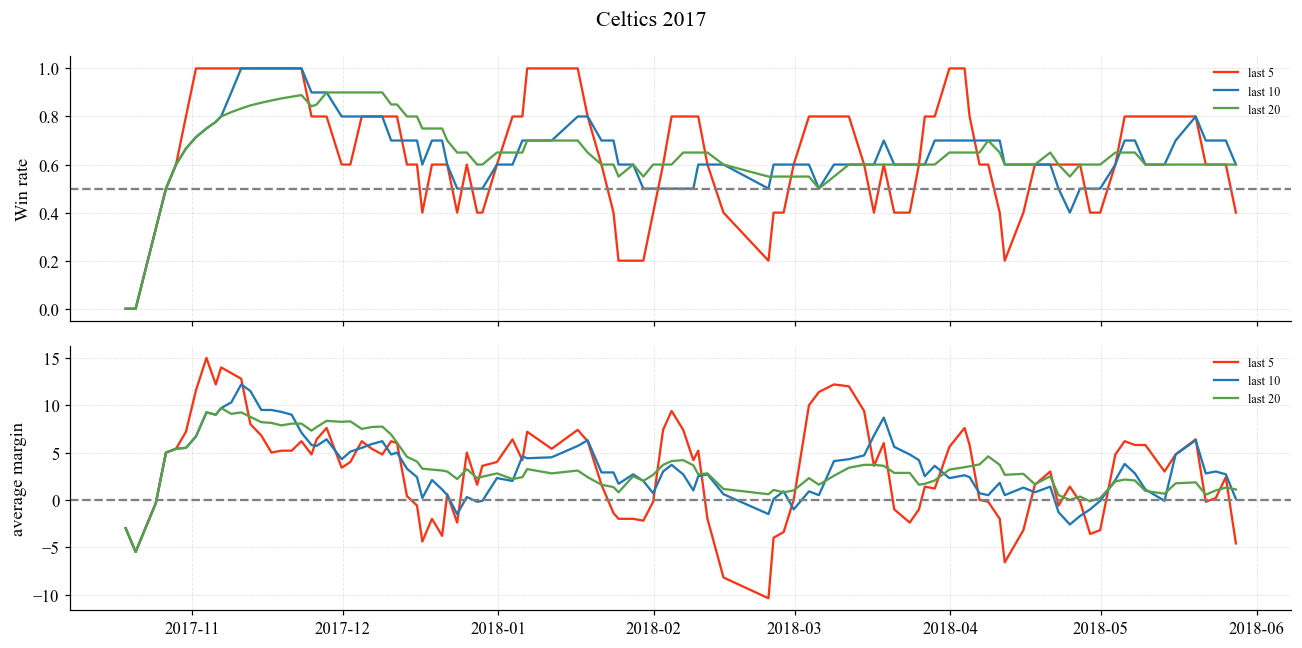

In [34]:
# quick check 
team = "Celtics"
szn = 2017

sample = team_games[
    (team_games.teamName == team) & (team_games.season == szn)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(sample.gameDate, sample.win_rate_last_5,  label="last 5",  color="#f93414")
axes[0].plot(sample.gameDate, sample.win_rate_last_10, label="last 10", color="#1f77b4")
axes[0].plot(sample.gameDate, sample.win_rate_last_20, label="last 20", color="#57A048")
axes[0].axhline(0.5, color="gray", linestyle="--")
axes[0].set_ylabel("Win rate")
axes[0].legend()

axes[1].plot(sample.gameDate, sample.avg_margin_last_5,  label="last 5",  color="#f93414")
axes[1].plot(sample.gameDate, sample.avg_margin_last_10, label="last 10", color="#1f77b4")
axes[1].plot(sample.gameDate, sample.avg_margin_last_20, label="last 20", color="#57A048")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_ylabel("average margin")
axes[1].legend()

plt.suptitle(f"{team} {szn}")
plt.tight_layout()
plt.show()

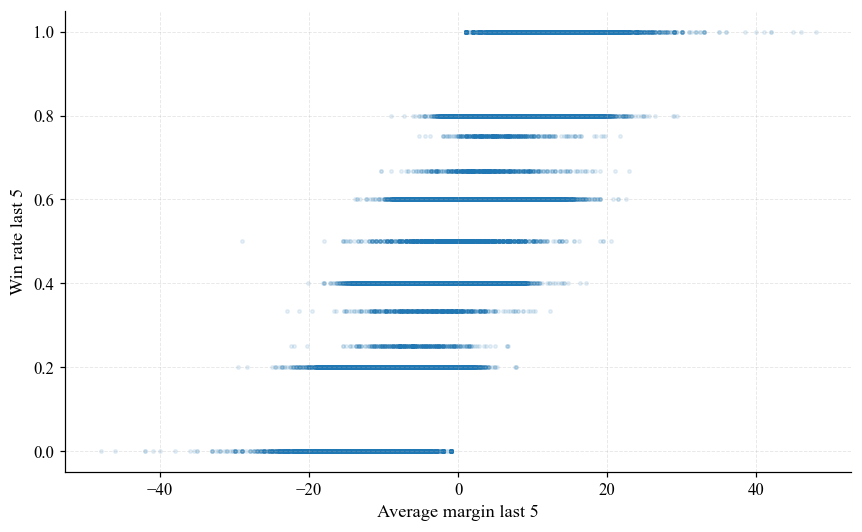

Correlation: 0.85


In [40]:
# kind of obvious and intuitve but looking at correlation between average points and wins 
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(team_games.avg_margin_last_5, team_games.win_rate_last_5, alpha=0.1, s=5, color="#1f77b4")
ax.set_xlabel("Average margin last 5")
ax.set_ylabel("Win rate last 5")
plt.tight_layout()
plt.show()

print(f"Correlation: {team_games['avg_margin_last_5'].corr(team_games['win_rate_last_5']):.2f}")

## 5. Rest days

Cheking for rest days: No rest worse perforemance to be expected. 1 day = back-to-back


In [46]:
team_games["days_since_last_game"] = (
    team_games.groupby("teamId")["gameDate"]
    .diff() # subracts the date of previous game
    .dt.days # converts to int
    .fillna(12) # if no previous game assume fully rested- 12 just default - you may change
)
team_games["is_back_to_back"] = (team_games.days_since_last_game <= 1).astype(int) # checks if played yesterday True 1, False 0

print("Rest day distribution (top 10):")

print(team_games.days_since_last_game.value_counts().head(10).sort_index())

print(f"\nShare of back-to-backs: {team_games.is_back_to_back.mean():.1%}")

Rest day distribution (top 10):
days_since_last_game
0.0     5009
1.0    47456
2.0    58471
3.0    20355
4.0     5521
5.0     1905
6.0     1002
7.0      474
8.0      288
9.0      151
Name: count, dtype: int64

Share of back-to-backs: 36.8%


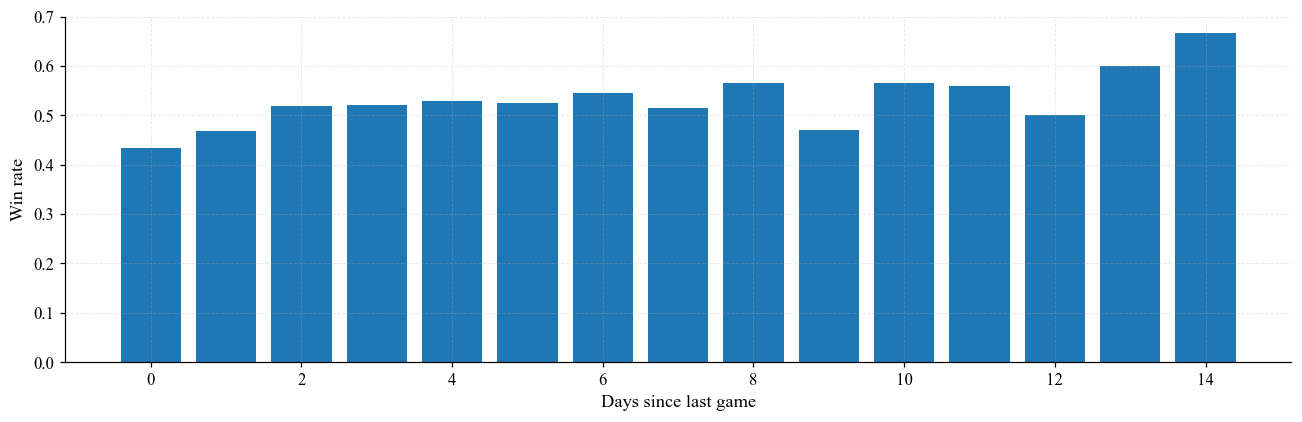

In [54]:
# check B2B correlation
rest_win = team_games.groupby("days_since_last_game").agg(
    win_rate=("win", "mean"),
    count=("win", "count")
).reset_index()

rest_win = rest_win[rest_win.days_since_last_game <= 14] # ignore everything with more than 2 weeks of rest

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(rest_win.days_since_last_game, rest_win.win_rate, color="#1f77b4")
ax.set_xlabel("Days since last game")
ax.set_ylabel("Win rate")
plt.tight_layout()
plt.show()


## 6. ELO rating

The **ELO system**  I am applying here is the same as in chess: every player/team has a score that gets adjusted after each match — the loser loses points, the winner gains them. How much depends on how *expected* the result was (underdog wins = big point shift).

Formula: `new_rating = old_rating + K * (actual - expected)`  
where `expected = 1 / (1 + 10**((opp - team) / 400))`

Initial ELO = 1500

The K-factor controls update speed. For NBA, K=20 is commonly used.

Home advantage bonus of +100 points.

In [57]:
INITIAL_ELO = 1500
K = 20
HOME_ADV = 100

elo = {}                  # teamId -> current ELO, Dic 
home_elo_pre = []         # home team ELO before the game, List
away_elo_pre = []         # away team ELO before the game, List

for row in df.itertuples(index=False):
    h, a = row.hometeamId, row.awayteamId # matching teams
    rh = elo.get(h, INITIAL_ELO) # checking current elo otherwise initial
    ra = elo.get(a, INITIAL_ELO)

    home_elo_pre.append(rh) # adding to list
    away_elo_pre.append(ra)

    expected_home = 1 / (1 + 10 ** (((ra) - (rh + HOME_ADV)) / 400)) # calc elo score
    actual_home = 1.0 if row.homeScore > row.awayScore else 0.0 # check the outcome 

    elo[h] = round(rh + K * (actual_home - expected_home), 1) # adjusting elo with outcome 
    elo[a] = round(ra + K * ((1 - actual_home) - (1 - expected_home)), 1)

df["home_elo_pre"] = home_elo_pre
df["away_elo_pre"] = away_elo_pre
df["elo_diff"] = df.home_elo_pre - df.away_elo_pre

df[["gameDate", "hometeamName", "awayteamName", "home_elo_pre", "away_elo_pre", "elo_diff", "home_win"]].tail(10)

,gameDate,hometeamName,awayteamName,home_elo_pre,away_elo_pre,elo_diff,home_win
71229,2026-04-24 20:00:00,Rockets,Lakers,1585.1,1638.1,-53.0,0
71230,2026-04-24 22:30:00,Trail Blazers,Spurs,1534.9,1693.0,-158.1,0
71231,2026-04-25 13:00:00,Magic,Pistons,1550.3,1651.3,-101.0,1
71232,2026-04-25 15:30:00,Suns,Thunder,1515.6,1762.9,-247.3,0
71233,2026-04-25 18:00:00,Hawks,Knicks,1580.5,1612.1,-31.6,0
71234,2026-04-25 20:30:00,Timberwolves,Nuggets,1604.9,1640.9,-36.0,1
71235,2026-04-26 13:00:00,Raptors,Cavaliers,1518.2,1629.4,-111.2,1
71236,2026-04-26 15:30:00,Trail Blazers,Spurs,1526.6,1701.3,-174.7,0
71237,2026-04-26 19:00:00,76ers,Celtics,1517.8,1680.4,-162.6,0
71238,2026-04-26 21:30:00,Rockets,Lakers,1573.8,1649.4,-75.6,1


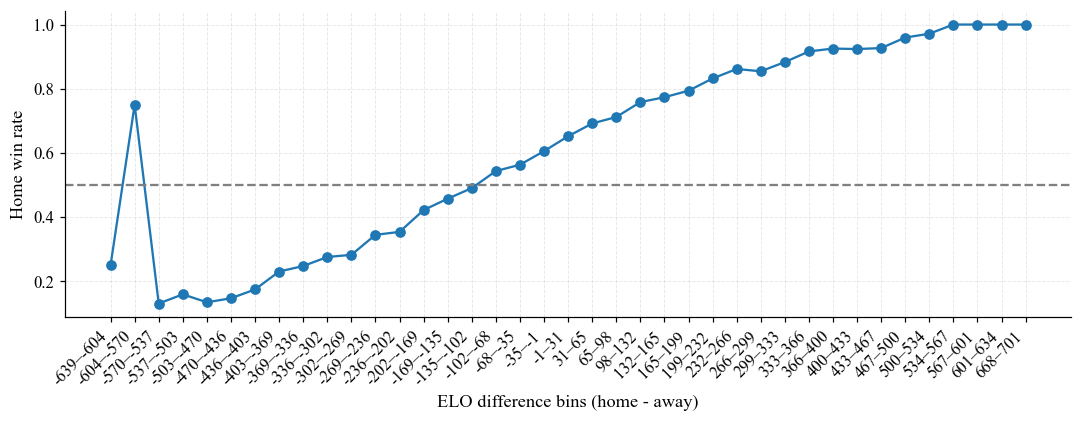

In [67]:
# ELo diff predict home wins?
fig, ax = plt.subplots(figsize=(10, 4))

df["elo_diff_bin"] = pd.cut(df.elo_diff, bins=40)
win_by_elo = df.groupby("elo_diff_bin", observed=True).home_win.agg(["mean", "count"])
win_by_elo["mean"].plot(ax=ax, marker="o", color="#1f77b4")


ax.set_xlabel("ELO difference bins (home - away)")
ax.set_ylabel("Home win rate")
ax.axhline(0.5, color="gray", linestyle="--")

# round the bin labels
labels = [f"{int(b.left)}–{int(b.right)}" for b in win_by_elo.index]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "elo_diff_home_win.png", dpi=300, bbox_inches="tight")

plt.show()
df = df.drop(columns=["elo_diff_bin"])

**Result:** The ELO difference seems to be a suffieceint indifactor for the home win rate.

**Observation:** Peak around -600 ELO is investigated in next cell 

In [66]:
# checking for the peak arounf -600 elo
df["elo_diff_bin"] = pd.cut(df.elo_diff, bins=40)
win_by_elo = df.groupby("elo_diff_bin", observed=True).home_win.agg(["mean", "count"])

print(win_by_elo[win_by_elo["mean"] > 0.7].head(10))
df = df.drop(columns=["elo_diff_bin"])

                          mean  count
elo_diff_bin                         
(-604.318, -570.835]  0.750000      4
(65.333, 98.815]      0.711790   4979
(98.815, 132.298]     0.758262   4418
(132.298, 165.78]     0.773518   3678
(165.78, 199.263]     0.793734   3064
(199.263, 232.745]    0.831891   2427
(232.745, 266.228]    0.861458   1920
(266.228, 299.71]     0.854355   1435
(299.71, 333.193]     0.882989   1017
(333.193, 366.675]    0.916159    656


Ok the peak just results form the fact of low statistics. 4 games is a small sample size. The tails of this statistics have to be taken with caution!

**Next:** Just to get an intuition for changing K and advantage values

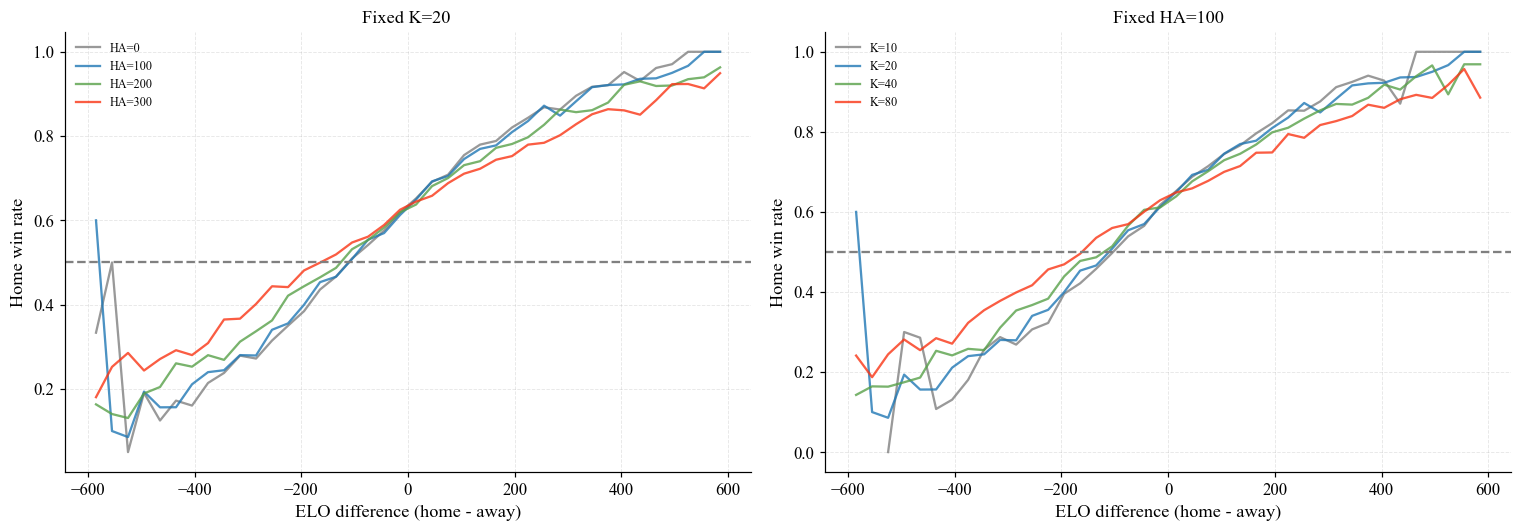

In [76]:
BINS = np.linspace(-600, 600, 41)

ha_configs = [
    ("HA=0",   20,   0, "gray"),
    ("HA=100", 20, 100, "#1f77b4"),
    ("HA=200", 20, 200, "#57A048"),
    ("HA=300", 20, 300, "#f93414"),
]

k_configs = [
    ("K=10",  10, 100, "gray"),
    ("K=20",  20, 100, "#1f77b4"),
    ("K=40",  40, 100, "#57A048"),
    ("K=80",  80, 100, "#f93414"),
]

def compute_elo(df, k, home_adv):
    elo = {}
    home_pre, away_pre = [], []
    for row in df.itertuples(index=False):
        h, a = row.hometeamId, row.awayteamId
        rh = elo.get(h, 1500)
        ra = elo.get(a, 1500)
        home_pre.append(rh)
        away_pre.append(ra)
        exp_home = 1 / (1 + 10 ** ((ra - (rh + home_adv)) / 400))
        actual   = 1.0 if row.homeScore > row.awayScore else 0.0
        elo[h]   = rh + k * (actual - exp_home)
        elo[a]   = ra + k * ((1 - actual) - (1 - exp_home))
    out = df.copy()
    out["home_elo_pre"] = home_pre
    out["away_elo_pre"] = away_pre
    out["elo_diff"]     = out.home_elo_pre - out.away_elo_pre
    return out

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, k, ha, color in ha_configs:
    tmp = compute_elo(df, k, ha)
    tmp["bin"] = pd.cut(tmp.elo_diff, bins=BINS)
    wb = tmp.groupby("bin", observed=True).home_win.mean()
    midpoints = [b.mid for b in wb.index]
    axes[0].plot(midpoints, wb.values, label=label, color=color, alpha=0.8)

axes[0].axhline(0.5, color="gray", linestyle="--")
axes[0].set_title("Fixed K=20 ")
axes[0].set_xlabel("ELO difference (home - away)")
axes[0].set_ylabel("Home win rate")
axes[0].legend()

for label, k, ha, color in k_configs:
    tmp = compute_elo(df, k, ha)
    tmp["bin"] = pd.cut(tmp.elo_diff, bins=BINS)
    wb = tmp.groupby("bin", observed=True).home_win.mean()
    midpoints = [b.mid for b in wb.index]
    axes[1].plot(midpoints, wb.values, label=label, color=color, alpha=0.8)

axes[1].axhline(0.5, color="gray", linestyle="--")
axes[1].set_title("Fixed HA=100")
axes[1].set_xlabel("ELO difference (home - away)")
axes[1].set_ylabel("Home win rate")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Head-to-head

Win rate of the home team against this specific opponent in the last **5 meetings** — regardless of where.

Example: BOS vs ATL — if BOS lost the last 3 against them, that should be a signal.

This might be underestimated. Imagine a setup of 5 athletes that win against every team. But there is one team not overwelmingly performing in the season but guarding their tactics perfectly. Unlikely but possible.

In [77]:
# track running history per unordered team pair
from collections import defaultdict, deque

H2H_WINDOW = 5
history = defaultdict(lambda: deque(maxlen=H2H_WINDOW))   # dictionary: key = team pair, value = last 5 winners

h2h_home_winrate = []

for row in df.itertuples(index=False):
    # BOS vs LAL == LAL vs BOS — order doesnt matter
    key = frozenset({row.hometeamId, row.awayteamId})
    past = history[key] # last 5 winners between these two teams
     
    if past:
        wins_for_current_home = sum(1 for winner in past if winner == row.hometeamId)
        h2h_home_winrate.append(wins_for_current_home / len(past))
    else:
        h2h_home_winrate.append(np.nan)   # never played each other before
    #update: who won this game?
    winner_id = row.hometeamId if row.homeScore > row.awayScore else row.awayteamId
    history[key].append(winner_id)
    
df["h2h_home_winrate_last5"] = h2h_home_winrate
df["h2h_home_winrate_last5"] = df["h2h_home_winrate_last5"].fillna(0.5)   # neutral if no history yet
df[["hometeamName", "awayteamName", "h2h_home_winrate_last5", "home_win"]].tail(5)

,hometeamName,awayteamName,h2h_home_winrate_last5,home_win
71234,Timberwolves,Nuggets,0.6,1
71235,Raptors,Cavaliers,0.6,1
71236,Trail Blazers,Spurs,0.4,0
71237,76ers,Celtics,0.4,0
71238,Rockets,Lakers,0.0,1


## 8. Merge back to game representation

Features are extracted from `team_games` (one row per team per game). Now I merge them back into `df` (one row per game). This is important as I train the ML model on games (events) but calculated my features per team. So I need to merge them back. 

Each game in `team_games` shows up twice — once for the home team, once for the away team. So I merge twice: once matching the home teamId (gives `home_` prefix), once matching the away teamId (gives `away_` prefix). The prefixes stop the columns from overwriting each other.

End goal looks something like this:

| gameId | hometeamId | awayteamId | home_win | home_win_rate_last_5 | away_win_rate_last_5 |
|--------|------------|------------|----------|----------------------|----------------------|
| 1      | BOS        | LAL        | 1        | 0.8                  | 0.4                  |


In [78]:
# columns I want to bring from team_games to df
rolling_cols = (
    [f"win_rate_last_{w}" for w in windows]
    + [f"avg_margin_last_{w}" for w in windows]
    + ["days_since_last_game", "is_back_to_back"]
)

# key features
team_features = team_games[["gameId", "teamId"] + rolling_cols]

# home features
df = df.merge(
    team_features.rename(columns={c: f"home_{c}" for c in rolling_cols} | {"teamId": "hometeamId"}),
    on=["gameId", "hometeamId"], how="left"
)
# away features
df = df.merge(
    team_features.rename(columns={c: f"away_{c}" for c in rolling_cols} | {"teamId": "awayteamId"}),
    on=["gameId", "awayteamId"], how="left"
)

print(f"Final columns: {df.shape[1]}")
print(df.columns.tolist())

Final columns: 32
['gameId', 'gameDate', 'gameType', 'hometeamId', 'hometeamName', 'awayteamId', 'awayteamName', 'homeScore', 'awayScore', 'home_win', 'point_diff', 'season', 'home_elo_pre', 'away_elo_pre', 'elo_diff', 'h2h_home_winrate_last5', 'home_win_rate_last_5', 'home_win_rate_last_10', 'home_win_rate_last_20', 'home_avg_margin_last_5', 'home_avg_margin_last_10', 'home_avg_margin_last_20', 'home_days_since_last_game', 'home_is_back_to_back', 'away_win_rate_last_5', 'away_win_rate_last_10', 'away_win_rate_last_20', 'away_avg_margin_last_5', 'away_avg_margin_last_10', 'away_avg_margin_last_20', 'away_days_since_last_game', 'away_is_back_to_back']


## 9. Difference of Features
In preperation of the next step I will simpy calc the difference between featuers eg. `home_win_rate=0.7` and `away_win_rate=0.5` -> `win_rate_diff=0.2`. Just small prep step:

In [79]:
for w in windows:
    df[f"win_rate_diff_{w}"] = df[f"home_win_rate_last_{w}"] - df[f"away_win_rate_last_{w}"]
    df[f"margin_diff_{w}"] = df[f"home_avg_margin_last_{w}"] - df[f"away_avg_margin_last_{w}"]

df["rest_diff"] = df.home_days_since_last_game - df.away_days_since_last_game

df.head(3)

,gameId,gameDate,gameType,hometeamId,hometeamName,awayteamId,awayteamName,homeScore,awayScore,home_win,point_diff,season,home_elo_pre,away_elo_pre,elo_diff,h2h_home_winrate_last5,home_win_rate_last_5,home_win_rate_last_10,home_win_rate_last_20,home_avg_margin_last_5,home_avg_margin_last_10,home_avg_margin_last_20,home_days_since_last_game,home_is_back_to_back,away_win_rate_last_5,away_win_rate_last_10,away_win_rate_last_20,away_avg_margin_last_5,away_avg_margin_last_10,away_avg_margin_last_20,away_days_since_last_game,away_is_back_to_back,win_rate_diff_5,margin_diff_5,win_rate_diff_10,margin_diff_10,win_rate_diff_20,margin_diff_20,rest_diff
0,24600052,1946-11-26 19:00:00,Regular Season,1610612744,Warriors,1610612738,Celtics,66,54,1,12,1946,1500.0,1500.0,0.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,24600063,1946-11-30 19:00:00,Regular Season,1610612752,Knicks,1610612744,Warriors,64,60,1,4,1946,1500.0,1507.2,-7.2,0.5,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0,1.0,1.0,1.0,12.0,12.0,12.0,4.0,0,NaN,NaN,NaN,NaN,NaN,NaN,8.0
2,24600076,1946-12-05 19:00:00,Regular Season,1610612744,Warriors,1610612752,Knicks,62,51,1,11,1946,1499.8,1507.4,-7.6,0.0,0.5,0.5,0.5,4.0,4.0,4.0,5.0,0,1.0,1.0,1.0,4.0,4.0,4.0,5.0,0,-0.5,0.0,-0.5,0.0,-0.5,0.0,0.0


## 10. Save

Writing the finished feature dataset to `data/processed/` 

In [80]:
out_path = DATA_PROCESSED / "games_with_features.parquet"
df.to_parquet(out_path, index=False)
print(f"Saved: {out_path.resolve()}")
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")

Saved: C:\Users\Uni\Desktop\Code\nba-game-predictor\data\processed\games_with_features.parquet
Rows: 71,239  |  Columns: 39


## 11. Discussion

Here I want to mention two thoughts that are worth mentioning:

**1. ELO parameters are fixed:**  
I use `K=20` and `HOME_ADV=100`, which are reasonable defaults (eg. used in FiveThirtyEight's NBA ELO model), but I did not optimise them on this dataset.
For the purpose of this work it should be valid. If you try to beat the sports betting provider I'd recommend running a prpper grid search over `K` and `HOME_ADV` to finetune your assumptions ;D


**2. Player movement is ignored:**
My modle assumes that my teams are fixed across the whole season. This is why I ignored the single athlete performance until now. I am sure it is worth adding these in future to my model.
Scenarios as players get traded, signed mid-season, or injured long-term can effect the team performanc eduring the season. The fact that most contracts run full seasons softens this but its worth keeping this in mind and adding in future.
